# Utility Functions

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


def get_threshold(knn_matches):
    good_matches_length = 0
    good_matches = []
    for ratio_threshold in [0.85, 0.8, 0.75, 0.7, 0.65]:
        matches = []
        for match_pair in knn_matches:
            if len(match_pair) == 2:
                m, n = match_pair  # m is the best match, n is the second best match
                if m.distance < ratio_threshold * n.distance:
                    matches.append(m)
        if len(matches) > good_matches_length:
            good_matches_length = len(matches)
            threshold = ratio_threshold
            good_matches = matches

    return threshold or 0.7, good_matches


def create_panorama_with_proper_bounds(img1, img2, H):
    """Create panorama with properly calculated canvas size and positioning"""
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    # Get corners of img1 in homogeneous coordinates
    corners1 = np.float32([[0, 0], [w1, 0], [w1, h1], [0, h1]]).reshape(-1, 1, 2)
    corners2 = np.float32([[0, 0], [w2, 0], [w2, h2], [0, h2]]).reshape(-1, 1, 2)

    # Transform corners of img1 using homography
    transformed_corners1 = cv2.perspectiveTransform(corners1, H)

    # Combine all corners to find bounding box
    all_corners = np.concatenate((corners2, transformed_corners1), axis=0)

    # Find the bounding rectangle
    x_min, y_min = np.int32(all_corners.min(axis=0).ravel())
    x_max, y_max = np.int32(all_corners.max(axis=0).ravel())

    print(f"Bounding box: x=[{x_min}, {x_max}], y=[{y_min}, {y_max}]")

    # Create translation matrix to handle negative coordinates
    translation = np.array([[1, 0, -x_min], [0, 1, -y_min], [0, 0, 1]])

    # Apply translation to homography
    H_translated = translation @ H

    # Calculate output canvas size
    output_width = x_max - x_min
    output_height = y_max - y_min

    print(f"Output canvas size: {output_width} x {output_height}")

    # Warp img1 with the translated homography
    warped_img1 = cv2.warpPerspective(img1, H_translated, (output_width, output_height))

    # Create the result image
    result = warped_img1.copy()

    # Place img2 at the correct position (accounting for translation)
    img2_x_offset = -x_min
    img2_y_offset = -y_min

    print(f"Placing img2 at offset: ({img2_x_offset}, {img2_y_offset})")

    # Ensure we don't go out of bounds
    end_y = min(img2_y_offset + h2, output_height)
    end_x = min(img2_x_offset + w2, output_width)

    if img2_y_offset >= 0 and img2_x_offset >= 0:
        result[img2_y_offset:end_y, img2_x_offset:end_x] = img2[
            : end_y - img2_y_offset, : end_x - img2_x_offset
        ]

    return result

#  Image Alignment with RANSAC

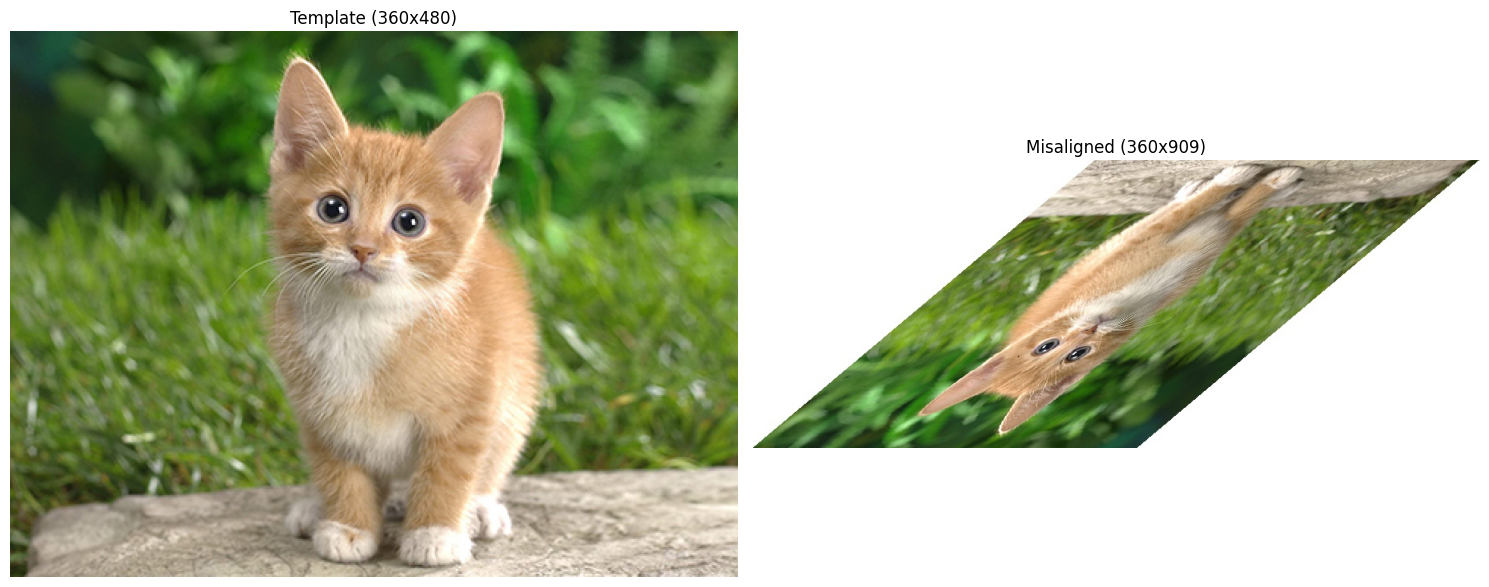

Template keypoints: 867
Misaligned keypoints: 869

Using ratio 0.85: 54 matches


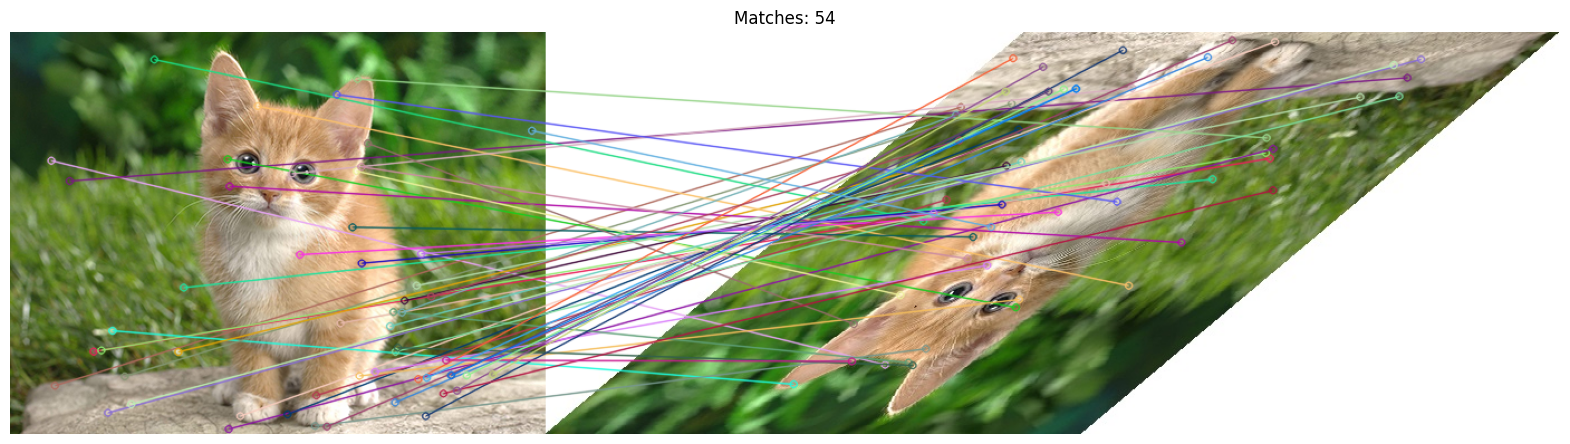

RANSAC inliers: 13 out of 54


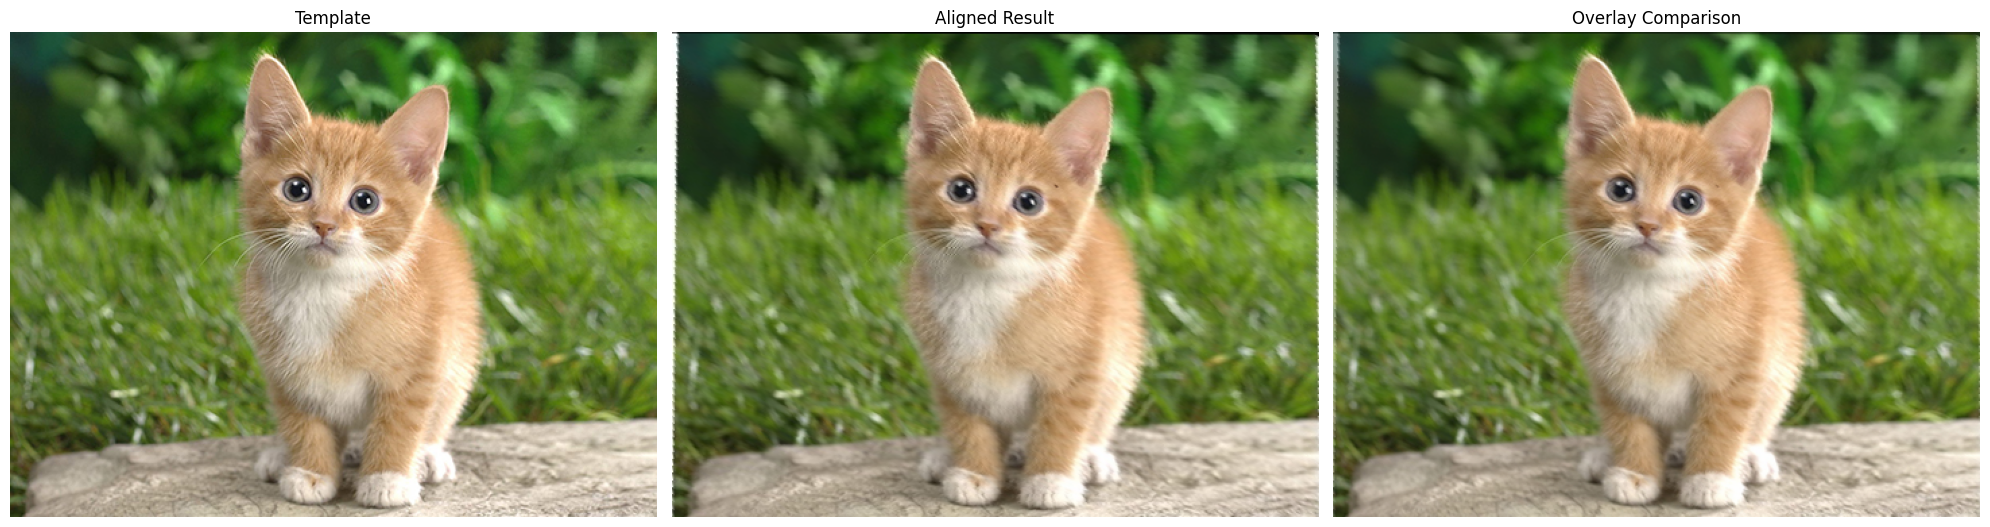

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

template_image = cv2.imread("images/cat.jpg")
misaligned_image = cv2.imread("images/cat_a.jpg")

# Visualize both images side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].imshow(cv2.cvtColor(template_image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Template (360x480)")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(misaligned_image, cv2.COLOR_BGR2RGB))
axes[1].set_title("Misaligned (360x909)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

grey_template = cv2.cvtColor(template_image, cv2.COLOR_BGR2GRAY)
grey_misaligned = cv2.cvtColor(misaligned_image, cv2.COLOR_BGR2GRAY)

detector = cv2.SIFT_create(nfeatures=2000)
kp1, desc1 = detector.detectAndCompute(grey_template, None)
kp2, desc2 = detector.detectAndCompute(grey_misaligned, None)

print(f"Template keypoints: {len(kp1)}")
print(f"Misaligned keypoints: {len(kp2)}")

# Use appropriate matcher based on descriptor type
matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
knn_matches = matcher.knnMatch(desc1, desc2, k=2)


ratio_threshold, good_matches = get_threshold(knn_matches)
print(f"\nUsing ratio {ratio_threshold}: {len(good_matches)} matches")

if len(good_matches) >= 4:  # Minimum for homography
    # Show matches
    img_matches = cv2.drawMatches(
        template_image,
        kp1,
        misaligned_image,
        kp2,
        good_matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )

    plt.figure(figsize=(20, 10))
    plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
    plt.title(f"Matches: {len(good_matches)}")
    plt.axis("off")
    plt.show()

    # Extract points
    points1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    points2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    h, mask = cv2.findHomography(
        points2,
        points1,
        cv2.RANSAC,
    )

    if h is not None and mask is not None:
        inliers = np.sum(mask)  # points that matches the homography
        print(f"RANSAC inliers: {inliers} out of {len(good_matches)}")

        if inliers >= 4:
            # Apply transformation
            height, width = template_image.shape[:2]
            aligned_image = cv2.warpPerspective(misaligned_image, h, (width, height))

            # Show results
            fig, axes = plt.subplots(1, 3, figsize=(20, 7))

            axes[0].imshow(cv2.cvtColor(template_image, cv2.COLOR_BGR2RGB))
            axes[0].set_title("Template")
            axes[0].axis("off")

            axes[1].imshow(cv2.cvtColor(aligned_image, cv2.COLOR_BGR2RGB))
            axes[1].set_title("Aligned Result")
            axes[1].axis("off")

            # Overlay
            overlay = cv2.addWeighted(template_image, 0.5, aligned_image, 0.5, 0)
            axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
            axes[2].set_title("Overlay Comparison")
            axes[2].axis("off")

            plt.tight_layout()
            plt.show()
        else:
            print("Not enough inliers for reliable homography")
    else:
        print("Could not compute homography")
else:
    print("Not enough matches - the images might not have sufficient overlap")

# Image Stitching


Using ratio 0.85: 569 matches


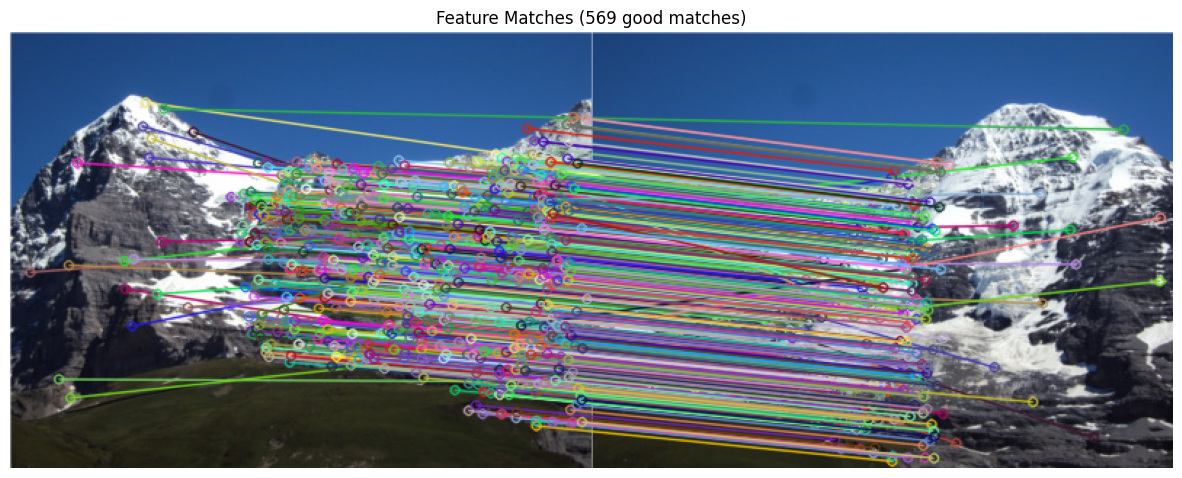

RANSAC inliers: 503 out of 569
Homography Matrix:
[[ 1.12278049e+00 -6.03942818e-02 -1.62926550e+02]
 [ 1.09696746e-01  1.06620512e+00 -2.94925045e+00]
 [ 3.52437868e-04 -8.90059780e-05  1.00000000e+00]]
Optimized bounding box: x=[-196, 410], y=[-12, 335]
Canvas size: 606 x 347


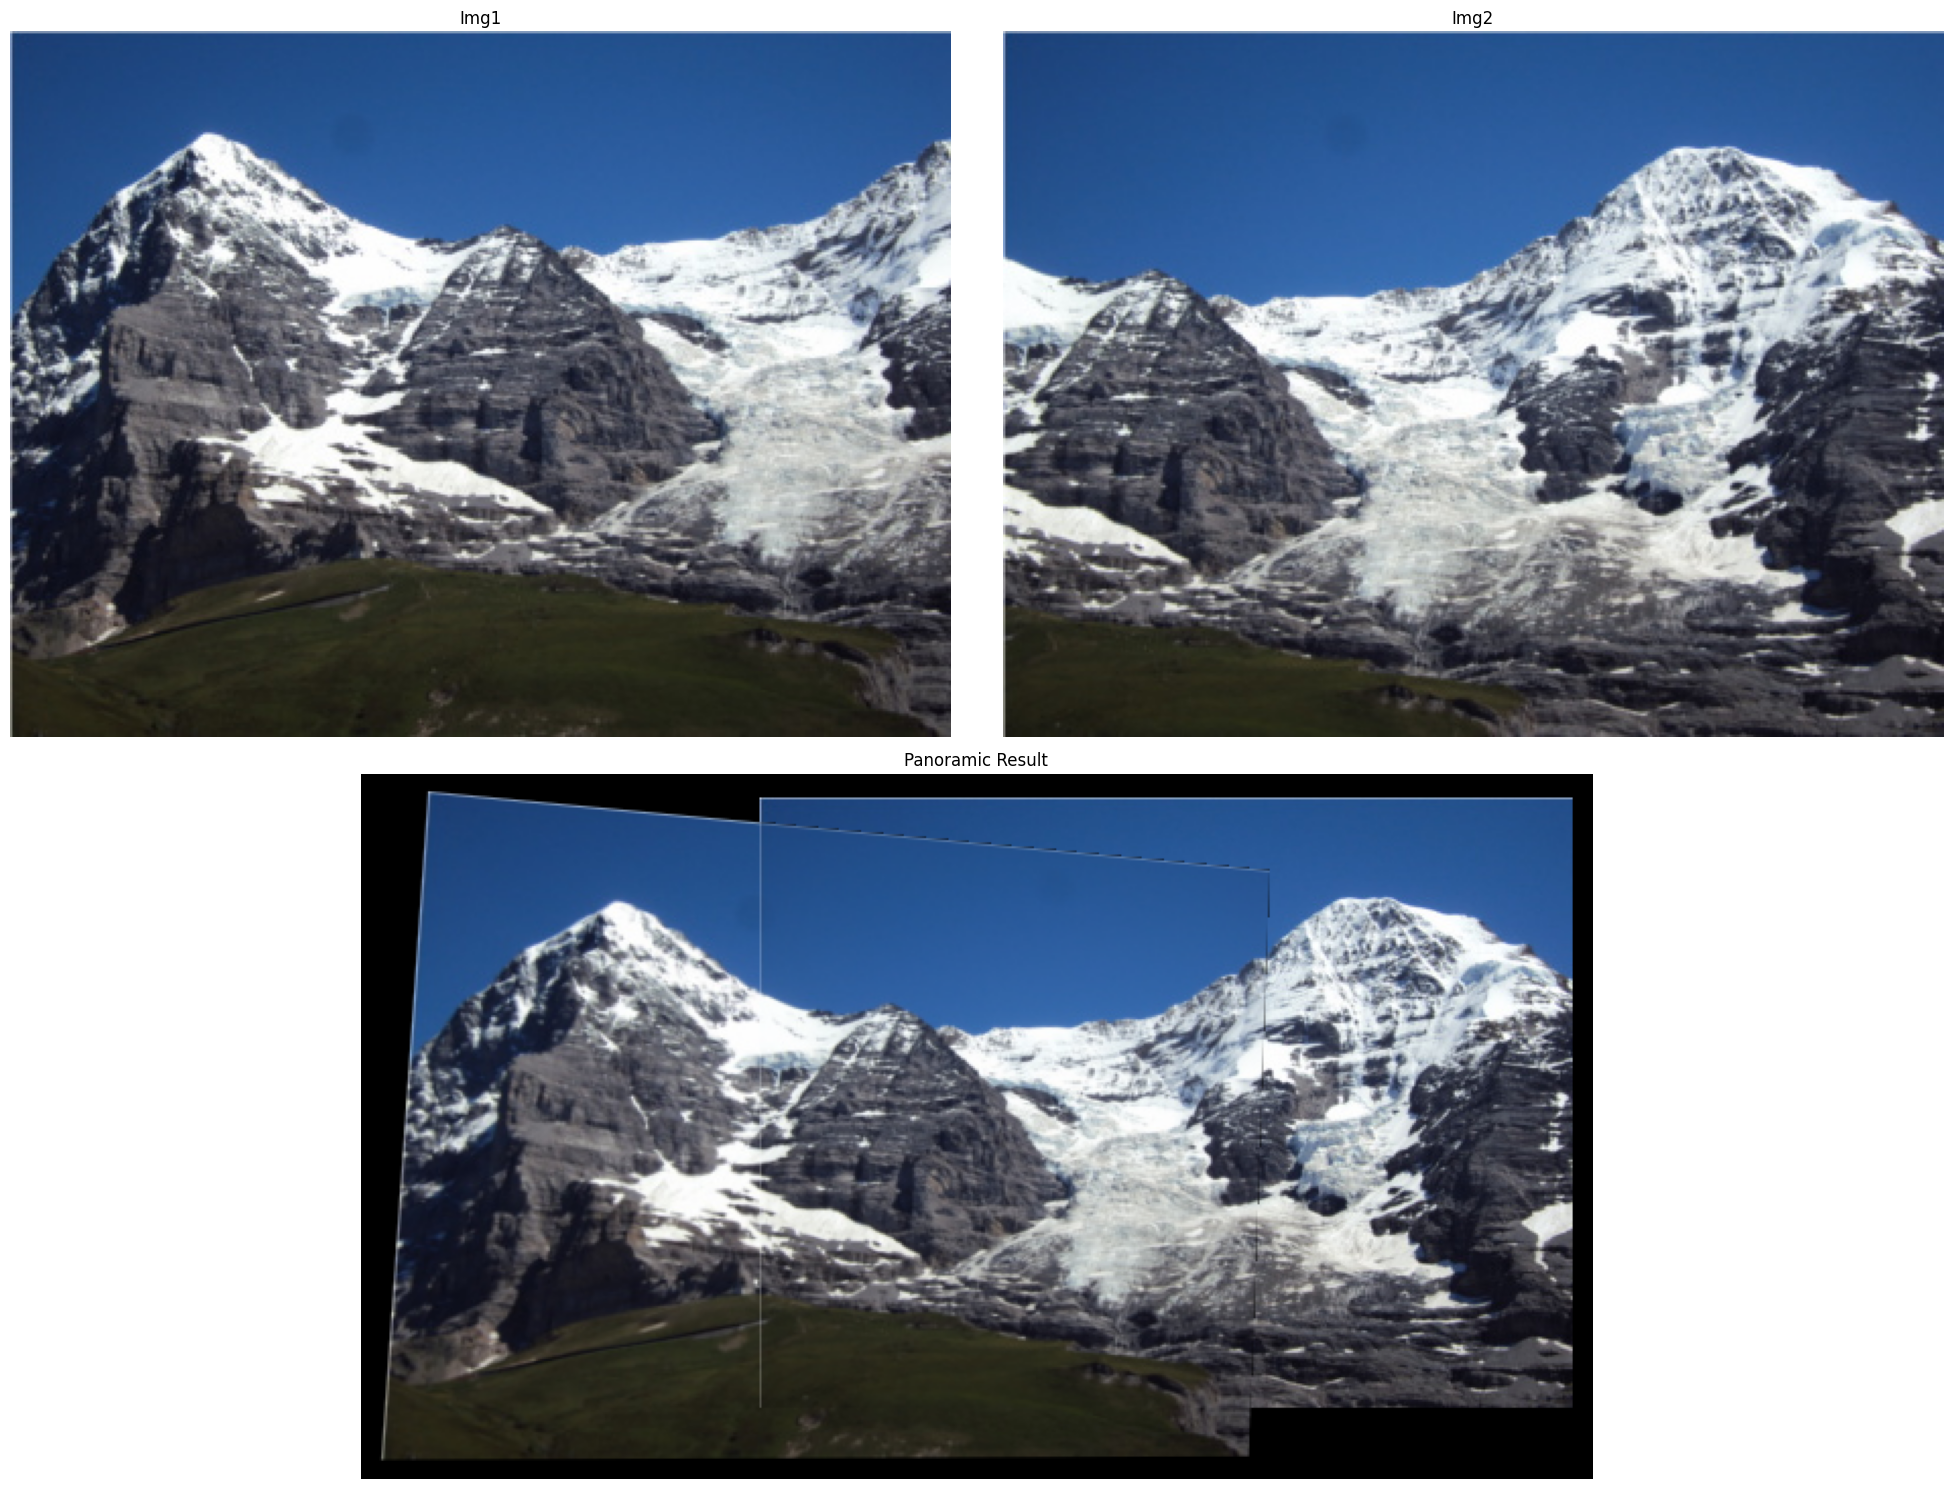

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


img1 = cv2.imread("images/img/hill1.JPG")
img2 = cv2.imread("images/img/hill2.JPG")
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

detector = cv2.SIFT_create()
kp1, desc1 = detector.detectAndCompute(img1_gray, None)
kp2, desc2 = detector.detectAndCompute(img2_gray, None)

matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
knn_matches = matcher.knnMatch(desc1, desc2, k=2)

ratio_threshold, good_matches = get_threshold(knn_matches)
print(f"\nUsing ratio {ratio_threshold}: {len(good_matches)} matches")

if len(good_matches) >= 4:  # Minimum for homography
    img3 = cv2.drawMatches(
        img1,
        kp1,
        img2,
        kp2,
        good_matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )

    plt.figure(figsize=(15, 8))
    plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
    plt.title(f"Feature Matches ({len(good_matches)} good matches)")
    plt.axis("off")
    plt.show()

    # Extract matched points
    pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])

    # estimate the homography between the sets of points
    (H, status) = cv2.findHomography(pts1, pts2, cv2.RANSAC)

    if H is not None and status is not None:
        inliers = np.sum(status)  # points that matches the homography
        print(f"RANSAC inliers: {inliers} out of {len(good_matches)}")
        print("Homography Matrix:")
        print(H)

        if inliers >= 4:
            result = create_panorama_with_proper_bounds(img1, img2, H)

            output_filename = "panorama_result.jpg"
            success = cv2.imwrite(output_filename, result)

            fig, axes = plt.subplots(2, 2, figsize=(20, 15))

            axes[0, 0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
            axes[0, 0].set_title("Img1")
            axes[0, 0].axis("off")

            axes[0, 1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
            axes[0, 1].set_title("Img2")
            axes[0, 1].axis("off")

            axes[1, 0].remove()
            axes[1, 1].remove()
            ax_result = fig.add_subplot(2, 1, 2)
            ax_result.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
            ax_result.set_title("Panoramic Result")
            ax_result.axis("off")

            plt.tight_layout()
            plt.show()
        else:
            print("Not enough inliers for homography")
    else:
        print("Homography estimation failed")
else:
    print("Not enough matches for homography")